In [1]:
import os 
from collections import defaultdict
import numpy as np
import pandas as pd 
import geopandas as gpd 
from shapely.geometry import Point, Polygon
from sklearn.neighbors import KernelDensity  # for calculating KDE
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import pairwise_distances_argmin
from sklearn.datasets import make_blobs
from sklearn import metrics
from sklearn.cluster import DBSCAN
from scipy import spatial  # for the kd-tree (see week 5): https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.KDTree.html 

from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib_scalebar.scalebar import ScaleBar  # https://pypi.org/project/matplotlib-scalebar/

from utils_week05 import gen_grid
from utils_week07 import run_kde, run_kmeans, run_voronoi, run_std_ellipse, run_convex_hull

In [2]:
os.listdir('../resources')  ## check your own folder location and change the path accordiningly

['hdb_data_2023.csv.xz',
 'GE5230 Reflection Sheet.docx',
 'segamat',
 'citydata-date_2020-09-15.csv.xz',
 'master-plan-2019-planningarea.zip',
 'citydata-Queenstown-20200915.csv.xz',
 'citydata-head_sample.csv',
 'hdb_data_2013.csv.xz',
 '.ipynb_checkpoints',
 'master-plan-2019-subzone_landuse_area.zip']

load background data

PROJCS["SVY21",GEOGCS["GCS_SVY21[WGS84]",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",1.36666666666667],PARAMETER["central_meridian",103.833333333333],PARAMETER["scale_factor",1],PARAMETER["false_easting",28001.642],PARAMETER["false_northing",38744.572],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


<Axes: >

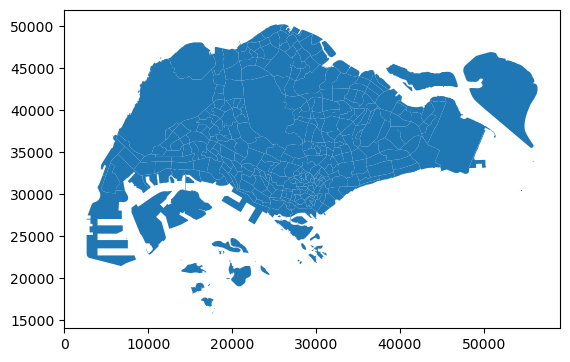

In [2]:
subz = gpd.read_file('../resources/master-plan-2019-subzone_landuse_area.zip')  # point to your own file location
print(subz.crs)
subz.plot()

## load point data

In [4]:
QT = pd.read_csv('../resources/citydata-Queenstown-20200915.csv.xz', index_col=0)
QT.head()

,did,idtype,lat,lon,hAccuracy,xx,yy,ts,time,date,year,month,day,hour,dow,hour_group
2673273,N2RsN3BwNGIxMjZmbzoyN2U5cWFhMmIyOTIy,0.0,1.294254,103.806134,8,24974.593238,30737.566695,1600099206,2020-09-15 00:00:06+08:00,2020-09-15,2020,9,15,0,1,0
2673379,OXYzMWg0ZmZsdmRkbzppNzNqZ2tkdXZqZzE=,0.0,1.298233,103.789671,6,23142.412105,31177.569719,1600099212,2020-09-15 00:00:12+08:00,2020-09-15,2020,9,15,0,1,0
2673481,YWhxajNwcjBmbGMzYzo5MHJpYTBtbHA0ZWxn,1.0,1.292214,103.779917,8,22056.864227,30512.040283,1600099217,2020-09-15 00:00:17+08:00,2020-09-15,2020,9,15,0,1,0
2673556,dW5ram80ZzJ1dW02OjRvZTJvMzY2ZDgzZ2g=,0.0,1.290708,103.787108,11,22857.157744,30345.498826,1600099222,2020-09-15 00:00:22+08:00,2020-09-15,2020,9,15,0,1,0
2673624,NjE3ZDlzcWNva284NDpkZHRwNjRoZjJnMXE1,0.0,1.284273,103.781231,6,22203.083197,29633.962100,1600099225,2020-09-15 00:00:25+08:00,2020-09-15,2020,9,15,0,1,0


<Axes: >

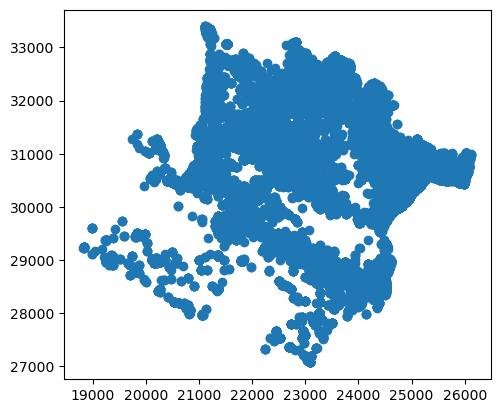

In [5]:
QT = gpd.GeoDataFrame(QT, geometry=[Point(x, y) for i, (x, y) in QT[['xx', 'yy']].iterrows()], crs=subz.crs)
QT.plot()

In [6]:

hour_group = {
    0: 'midnight',  # 00-04
    1: 'morning commuting',  # 04-08
    2: 'before lunch',  # 08-12
    3: 'after lunch',  # 12-16
    4: 'evening commuting',  # 16-20
    5: 'night',  # 20-24
}

## prepare grid

In [6]:
xmin, ymin, xmax, ymax = QT.total_bounds
xlim = [xmin, xmax]
ylim = [ymin, ymax]
xmin, ymin, xmax, ymax

(18824.251366038203, 27070.378120247427, 26126.57110678148, 33394.86029353935)

7302.319740743278 6324.482173291923
74 64 4736


100%|█████████████████████████████████████████████████████| 4736/4736 [00:00<00:00, 99606.49it/s]

   box_id  col_id  row_id                                           geometry  \
0       0       0       0  POLYGON ((18819.070 27070.378, 18819.070 27169...   
1       1       1       0  POLYGON ((18917.890 27070.378, 18917.890 27169...   
2       2       2       0  POLYGON ((19016.710 27070.378, 19016.710 27169...   
3       3       3       0  POLYGON ((19115.530 27070.378, 19115.530 27169...   
4       4       4       0  POLYGON ((19214.350 27070.378, 19214.350 27169...   

              x             y  
0  18868.479997  27119.788137  
1  18967.300031  27119.788137  
2  19066.120065  27119.788137  
3  19164.940099  27119.788137  
4  19263.760133  27119.788137  


<Axes: >

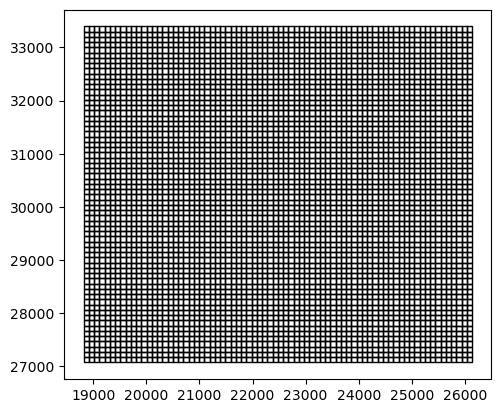

In [7]:
crs = QT.crs

size = 100
len_x = xmax - xmin
len_y = ymax - ymin

print(len_x, len_y)

ncol = int(np.ceil(len_x/size))
nrow = int(np.ceil(len_y/size))
print(ncol, nrow, ncol*nrow)

grid = gen_grid(xmin, ymin, xmax, ymax, ncol=ncol, nrow=nrow, force_square=True, crs=crs)
cent = grid.centroid
grid['x'] = cent.x
grid['y'] = cent.y

print(grid.head())
grid.plot(fc='none', ec='k')

## let's start with KDE (for all)

In [8]:
grid_data = grid[['x', 'y']]
grid_data = np.array(grid_data)
grid_data, grid_data.shape

(array([[18868.47999695, 27119.78813723],
        [18967.30003091, 27119.78813723],
        [19066.12006487, 27119.78813723],
        ...,
        [25884.70240795, 33345.45027656],
        [25983.52244191, 33345.45027656],
        [26082.34247587, 33345.45027656]]),
 (4736, 2))

In [9]:
print(QT.head())
all_pts = QT[['xx', 'yy']]

                                          did  idtype       lat         lon  \
2673273  N2RsN3BwNGIxMjZmbzoyN2U5cWFhMmIyOTIy     0.0  1.294254  103.806134   
2673379  OXYzMWg0ZmZsdmRkbzppNzNqZ2tkdXZqZzE=     0.0  1.298233  103.789671   
2673481  YWhxajNwcjBmbGMzYzo5MHJpYTBtbHA0ZWxn     1.0  1.292214  103.779917   
2673556  dW5ram80ZzJ1dW02OjRvZTJvMzY2ZDgzZ2g=     0.0  1.290708  103.787108   
2673624  NjE3ZDlzcWNva284NDpkZHRwNjRoZjJnMXE1     0.0  1.284273  103.781231   

         hAccuracy            xx            yy          ts  \
2673273          8  24974.593238  30737.566695  1600099206   
2673379          6  23142.412105  31177.569719  1600099212   
2673481          8  22056.864227  30512.040283  1600099217   
2673556         11  22857.157744  30345.498826  1600099222   
2673624          6  22203.083197  29633.962100  1600099225   

                              time        date  year  month  day  hour  dow  \
2673273  2020-09-15 00:00:06+08:00  2020-09-15  2020      9   15     0   

In [10]:
kde_all = KernelDensity(kernel='exponential', bandwidth=400).fit(all_pts)
grid['all_dens'] = np.exp(kde_all.score_samples(grid_data))

kde_all

/home/benny/.pyenv/versions/miniconda3-3.9-4.12.0/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KernelDensity was fitted with feature names
  warnings.warn(


KernelDensity(bandwidth=400, kernel='exponential')

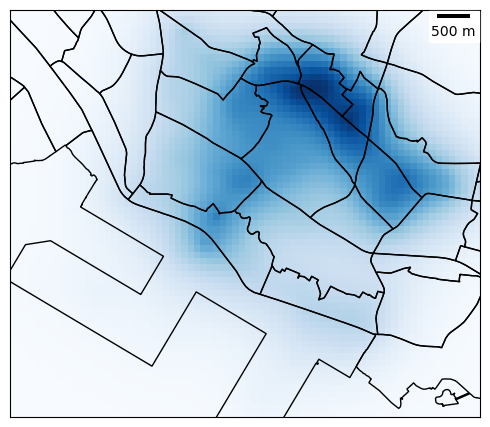

In [12]:

fig, ax = plt.subplots(figsize=(5,5))

grid.plot('all_dens', cmap='Blues', ax=ax)
subz.plot(fc='none', ec='k', ax=ax)

# Create scale bar
scalebar = ScaleBar(1, "m", fixed_value=500, fixed_units='m')
ax.add_artist(scalebar)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

### here run for the four hour groups


    1: 'morning commuting',  # 04-08
    2: 'before lunch',  # 08-12
    4: 'evening commuting',  # 16-20
    5: 'night',  # 20-24

In [13]:
this_pts = QT

new_cols = []
for i, hg in enumerate([1, 2, 4, 5]):
    tmp = this_pts[this_pts['hour_group']==hg]
    #c = [clrs[3]]*len(tmp)
    zs = run_kde(tmp, grid_data, bandwidth=400)  ## <---- go to script
    hg_col = 'hg_{}_dens'.format(hg)
    grid[hg_col] = zs  # store the KDE result to grid
    new_cols.append(hg_col)

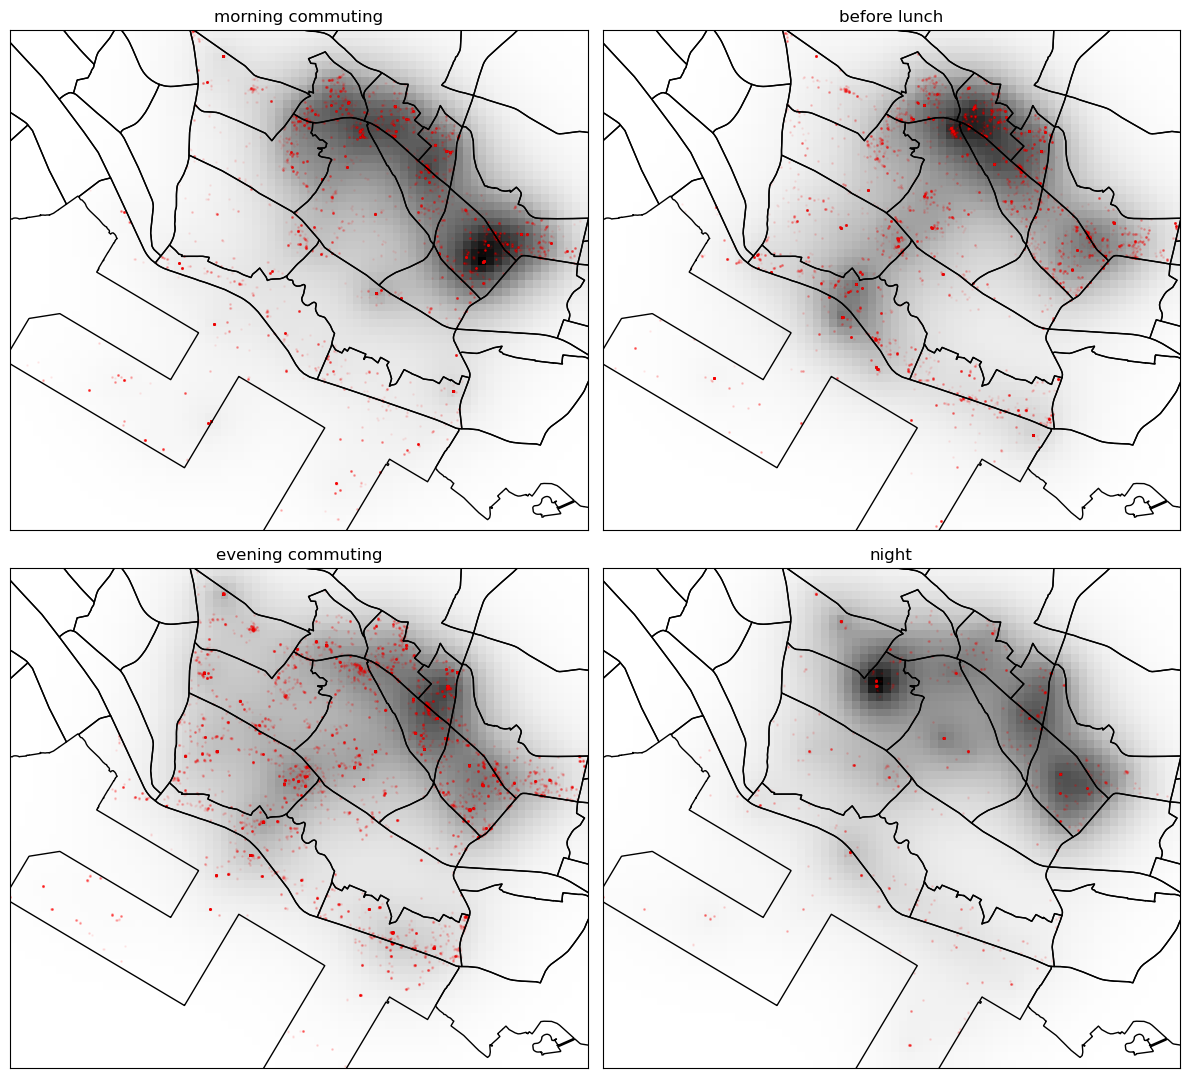

In [15]:


title_dict = {
0: 'midnight',
1: 'morning commuting',
2: 'before lunch',
3: 'after lunch',
4: 'evening commuting',
5: 'night',
}

fig, axg = plt.subplots(2, 2, figsize=(12, 11), sharex=True, sharey=True)
axs = axg.flatten()

vmax = grid[new_cols].max().max()

for i, hg in enumerate([1, 2, 4, 5]):
    ax = axs[i]
    tmp = this_pts[this_pts['hour_group']==hg]
    hg_col = 'hg_{}_dens'.format(hg)
    grid.plot(hg_col, cmap='Greys', vmin=0, vmax=vmax, ax=ax)
    tmp.plot(c='r', ax=ax, markersize=1, alpha=.05)
    subz.plot(fc='none', ec='k', ax=ax)

    ax.set_title(title_dict[hg])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    #break

plt.tight_layout()

## k-means clustering
### try visualise with Convex Hull

In [16]:
fg_clrs = sns.color_palette('muted')
bg_clrs = sns.color_palette('pastel')

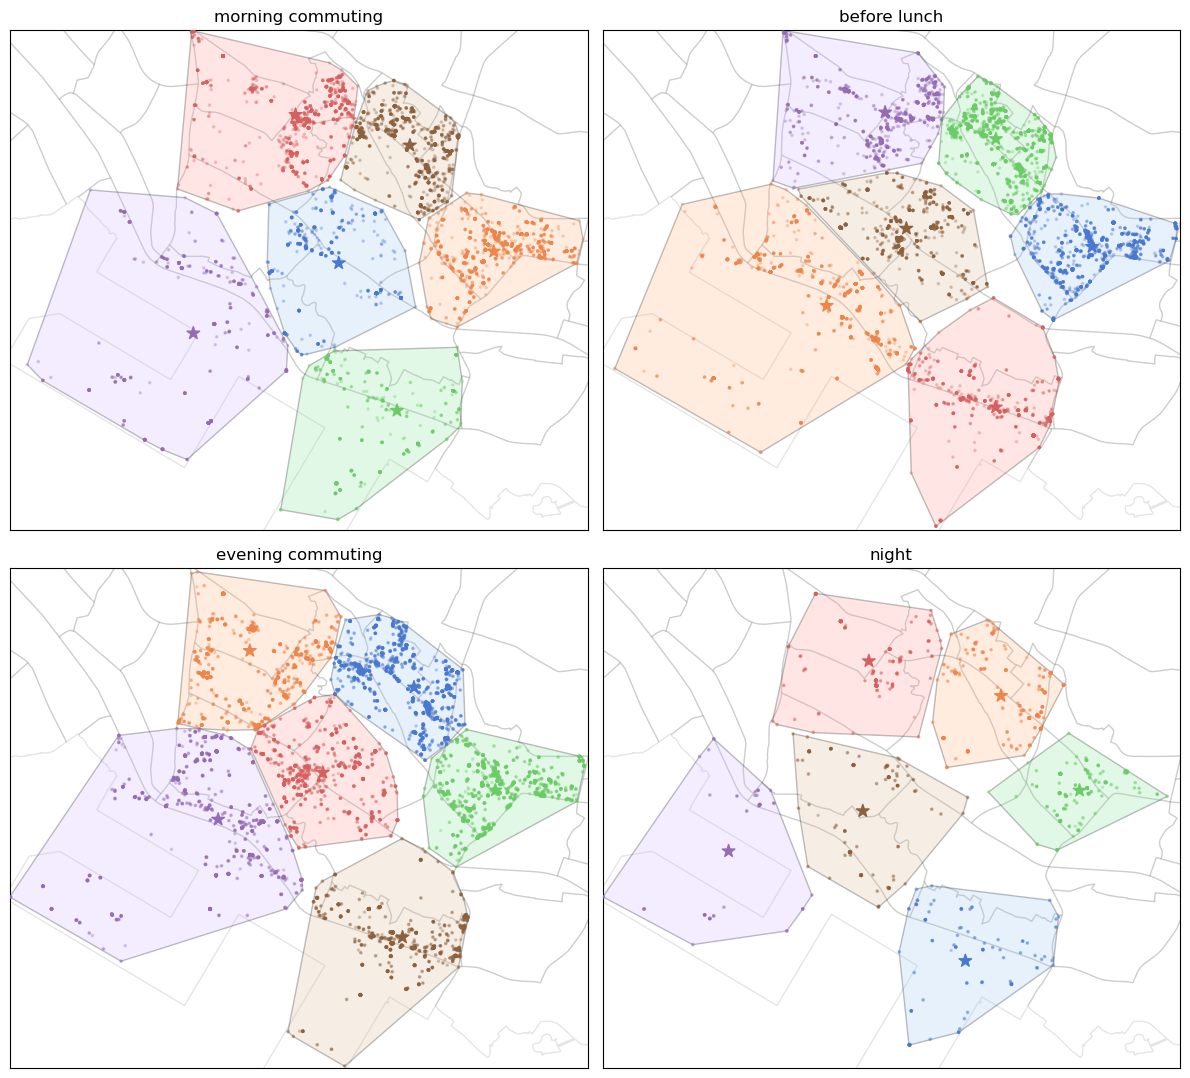

In [19]:

n_clusters = 6
this_pts = QT

x0, y0, x1, y1 = this_pts.total_bounds
xlim = (x0, x1)
ylim = (y0, y1)


fig, axg = plt.subplots(2, 2, figsize=(12, 11), sharex=True, sharey=True)
axs = axg.flatten()


title_dict = {
0: 'midnight',
1: 'morning commuting',
2: 'before lunch',
3: 'after lunch',
4: 'evening commuting',
5: 'night',
}

for i, hg in enumerate([1, 2, 4, 5]):
    ax = axs[i]
    this_gdf = this_pts[this_pts['hour_group']==hg].copy()  # <---here it is a copy, separated from the original DF, 
    # meaning it is a local temporary instance and it WILL DISAPPEAR after every loop (only the last instance (hg=5) will be kept after loop) 
    #Xb = np.array([this_gdf.geometry.x, this_gdf.geometry.y]).T
    k_means_labels, centers_gdf = run_kmeans(this_gdf, n_clusters)  # look at the script to see how it is run
    this_gdf['k'] = k_means_labels
    #print(this_gdf)
    
    hull_gdf = run_convex_hull(this_gdf, 'k')  # generate convex hull

    # plotting
    # plot the convex hull as backhgound
    hull_gdf.plot(fc=[bg_clrs[k] for k in hull_gdf['k']], 
                 alpha=0.25, ec='k',
                 zorder=2, ax=ax)
    #print(hull_gdf)

    # plot the points
    this_gdf.plot(color=[fg_clrs[k] for k in k_means_labels], 
                  marker=".", alpha=.25, markersize=10, 
                  zorder=5, ax=ax, )
    
    # plot the k-means centers
    centers_gdf.plot(color=[fg_clrs[k] for k in centers_gdf['k']],  
                     marker='*',
                     ax=ax,
                     zorder=6,
                     markersize=90,
                    )
    
    subz.plot(fc='none', ec='k', ax=ax, alpha=.1)
    
    ax.set_title(title_dict[hg])
    xlim = (x0, x1)
    ylim = (y0, y1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    ## nothing of the result is save; if you need to save them, try using some list/dictionary to keep the results

plt.tight_layout()

### same thing, but add the KDE background and remove points

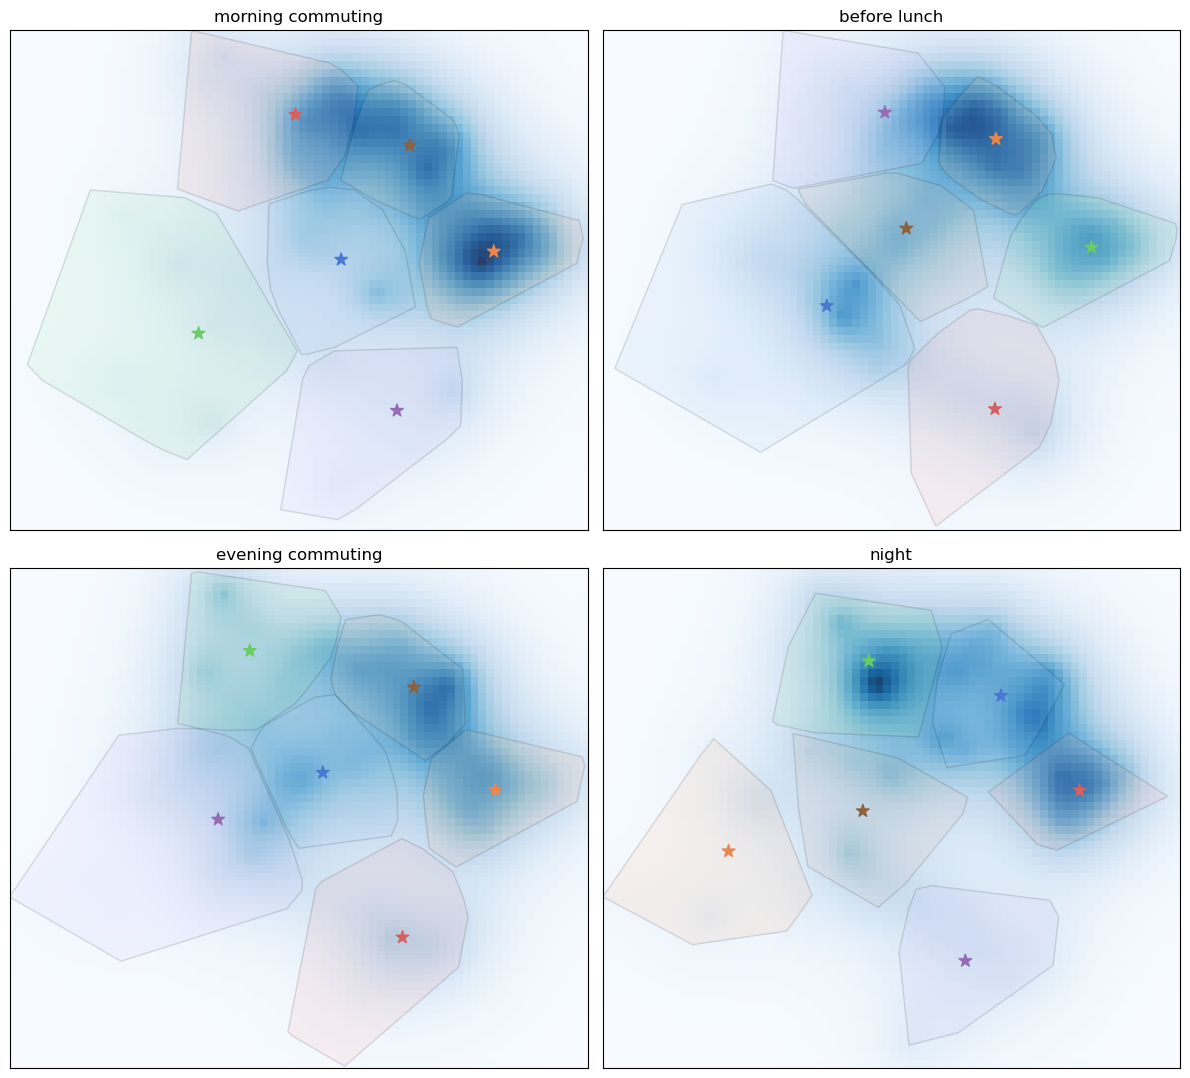

In [20]:

n_clusters = 6
this_pts = QT

x0, y0, x1, y1 = this_pts.total_bounds
xlim = (x0, x1)
ylim = (y0, y1)


fig, axg = plt.subplots(2, 2, figsize=(12, 11), sharex=True, sharey=True)
axs = axg.flatten()


title_dict = {
0: 'midnight',
1: 'morning commuting',
2: 'before lunch',
3: 'after lunch',
4: 'evening commuting',
5: 'night',
}

for i, hg in enumerate([1, 2, 4, 5]):
    ax = axs[i]
    this_gdf = this_pts[this_pts['hour_group']==hg].copy()
    #Xb = np.array([this_gdf.geometry.x, this_gdf.geometry.y]).T
    k_means_labels, centers_gdf = run_kmeans(this_gdf, n_clusters)
    this_gdf['k'] = k_means_labels
    #print(this_gdf)
    hg_col = 'hg_{}_dens'.format(hg)
    grid.plot(hg_col, cmap='Blues', vmin=0, vmax=vmax, ax=ax)
    
    hull_gdf = run_convex_hull(this_gdf, 'k')
    
    hull_gdf.plot(fc=[bg_clrs[k] for k in hull_gdf['k']], 
                 alpha=0.125, ec='k',
                 zorder=2, ax=ax)
    #print(hull_gdf)
    
    """this_gdf.plot(color=[fg_clrs[k] for k in k_means_labels], 
                  marker=".", alpha=.25, markersize=10, 
                  zorder=5, ax=ax, )
    """
    
    centers_gdf.plot(color=[fg_clrs[k] for k in centers_gdf['k']],  
                     marker='*',
                     ax=ax,
                     zorder=6,
                     markersize=90,
                    )
    
    ax.set_title(title_dict[hg])
    xlim = (x0, x1)
    ylim = (y0, y1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

### use standard ellipses instead of convex hull

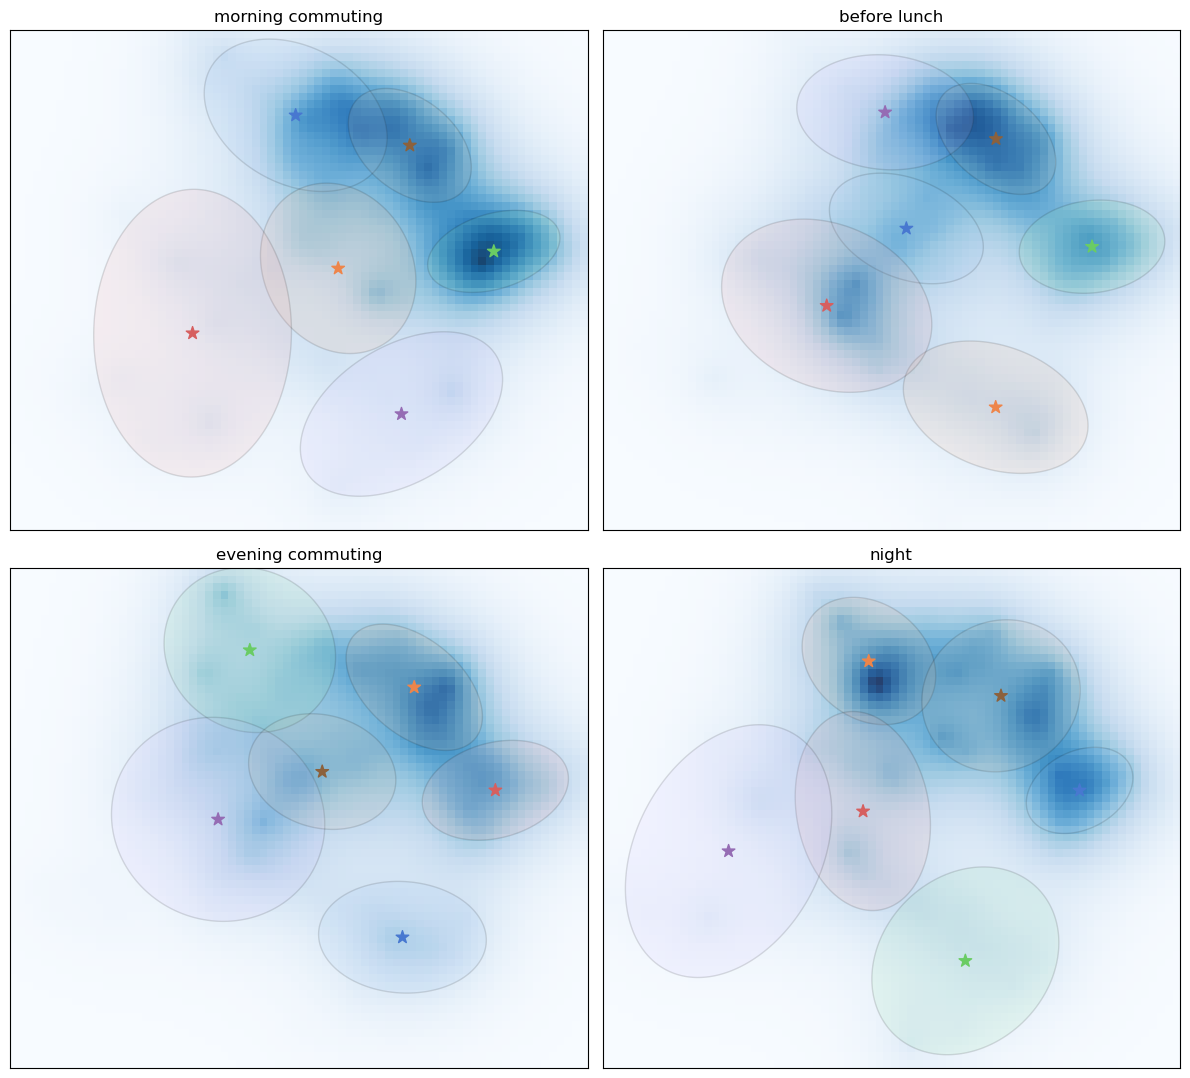

In [21]:

n_clusters = 6
this_pts = QT

x0, y0, x1, y1 = this_pts.total_bounds
xlim = (x0, x1)
ylim = (y0, y1)


fig, axg = plt.subplots(2, 2, figsize=(12, 11), sharex=True, sharey=True)
axs = axg.flatten()


title_dict = {
0: 'midnight',
1: 'morning commuting',
2: 'before lunch',
3: 'after lunch',
4: 'evening commuting',
5: 'night',
}

for i, hg in enumerate([1, 2, 4, 5]):
    ax = axs[i]
    this_gdf = this_pts[this_pts['hour_group']==hg].copy()
    #Xb = np.array([this_gdf.geometry.x, this_gdf.geometry.y]).T
    k_means_labels, centers_gdf = run_kmeans(this_gdf, n_clusters)
    this_gdf['k'] = k_means_labels
    #print(this_gdf)
    hg_col = 'hg_{}_dens'.format(hg)
    grid.plot(hg_col, cmap='Blues', vmin=0, vmax=vmax, ax=ax)
    
    elps_gdf = run_std_ellipse(this_gdf, 'k', n_std=2)
    elps_gdf.plot(fc=[bg_clrs[k] for k in elps_gdf['k']], 
                 alpha=0.125, ec='k',
                 zorder=2, ax=ax)
    #print(hull_gdf)
    
    """this_gdf.plot(color=[fg_clrs[k] for k in k_means_labels], 
                  marker=".", alpha=.25, markersize=10, 
                  zorder=5, ax=ax, )
    """
    
    centers_gdf.plot(color=[fg_clrs[k] for k in centers_gdf['k']],  
                     marker='*',
                     ax=ax,
                     zorder=6,
                     markersize=90,
                    )
    
    ax.set_title(title_dict[hg])
    xlim = (x0, x1)
    ylim = (y0, y1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

In [21]:
### replace the standard ellipses/convex hulls with Voronoi Polygon

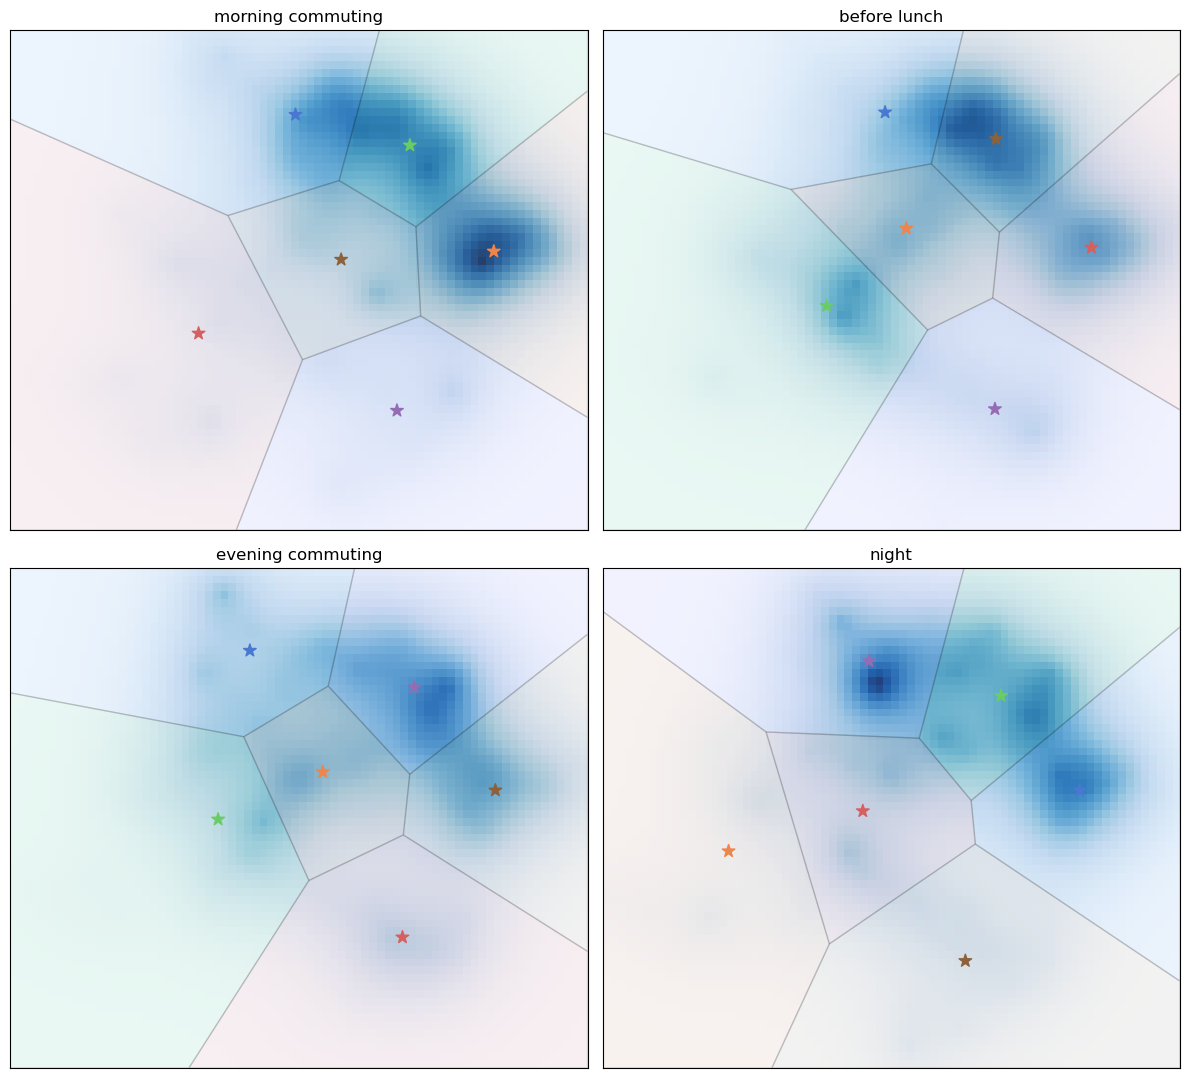

In [22]:

n_clusters = 6
this_pts = QT

x0, y0, x1, y1 = this_pts.total_bounds
xlim = (x0, x1)
ylim = (y0, y1)


fig, axg = plt.subplots(2, 2, figsize=(12, 11), sharex=True, sharey=True)
axs = axg.flatten()


title_dict = {
0: 'midnight',
1: 'morning commuting',
2: 'before lunch',
3: 'after lunch',
4: 'evening commuting',
5: 'night',
}

for i, hg in enumerate([1, 2, 4, 5]):
    ax = axs[i]
    this_gdf = this_pts[this_pts['hour_group']==hg].copy()
    #Xb = np.array([this_gdf.geometry.x, this_gdf.geometry.y]).T
    k_means_labels, centers_gdf = run_kmeans(this_gdf, n_clusters)
    this_gdf['k'] = k_means_labels
    #print(this_gdf)
    hg_col = 'hg_{}_dens'.format(hg)
    grid.plot(hg_col, cmap='Blues', vmin=0, vmax=vmax, ax=ax)
    
    vor_gdf = run_voronoi(centers_gdf, x0, y0, x1, y1)
    
    vor_gdf.plot(fc=[bg_clrs[k] for k in vor_gdf['k']], 
                 alpha=0.125, ec='k',
                 zorder=2, ax=ax)

    #print(hull_gdf)
    
    """this_gdf.plot(color=[fg_clrs[k] for k in k_means_labels], 
                  marker=".", alpha=.25, markersize=10, 
                  zorder=5, ax=ax, )
    """
    
    centers_gdf.plot(color=[fg_clrs[k] for k in centers_gdf['k']],  
                     marker='*',
                     ax=ax,
                     zorder=6,
                     markersize=90,
                    )
    
    ax.set_title(title_dict[hg])
    xlim = (x0, x1)
    ylim = (y0, y1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

calculating distortion and inertia for determining k

In [23]:
random_state = 42
K = range(1, 16)

evaluation_res = {}

for i, hg in enumerate([1, 2, 4, 5]):
    this_gdf = this_pts[this_pts['hour_group']==hg]
    Xb = np.array([this_gdf.geometry.x, this_gdf.geometry.y]).T

    # Initialize lists to store distortion and inertia values
    distortions = []
    inertias = []
    mapping1 = {}
    mapping2 = {}
    
    # Fit K-means for different values of k
    for k in K:
        #kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)
        k_means = KMeans(init="k-means++", n_clusters=k, n_init=10, random_state=random_state)
        k_means.fit(Xb)
        
        # Calculate distortion as the average squared distance from points to their cluster centers
        distortions.append(sum(np.min(cdist(Xb, k_means.cluster_centers_, 'euclidean'), axis=1)**2) / Xb.shape[0])
        
        # Inertia is calculated directly by KMeans
        inertias.append(k_means.inertia_)

    res = pd.DataFrame.from_dict({'k': K, 'distortion': distortions, 'inertia': inertias})
    evaluation_res[hg] = res

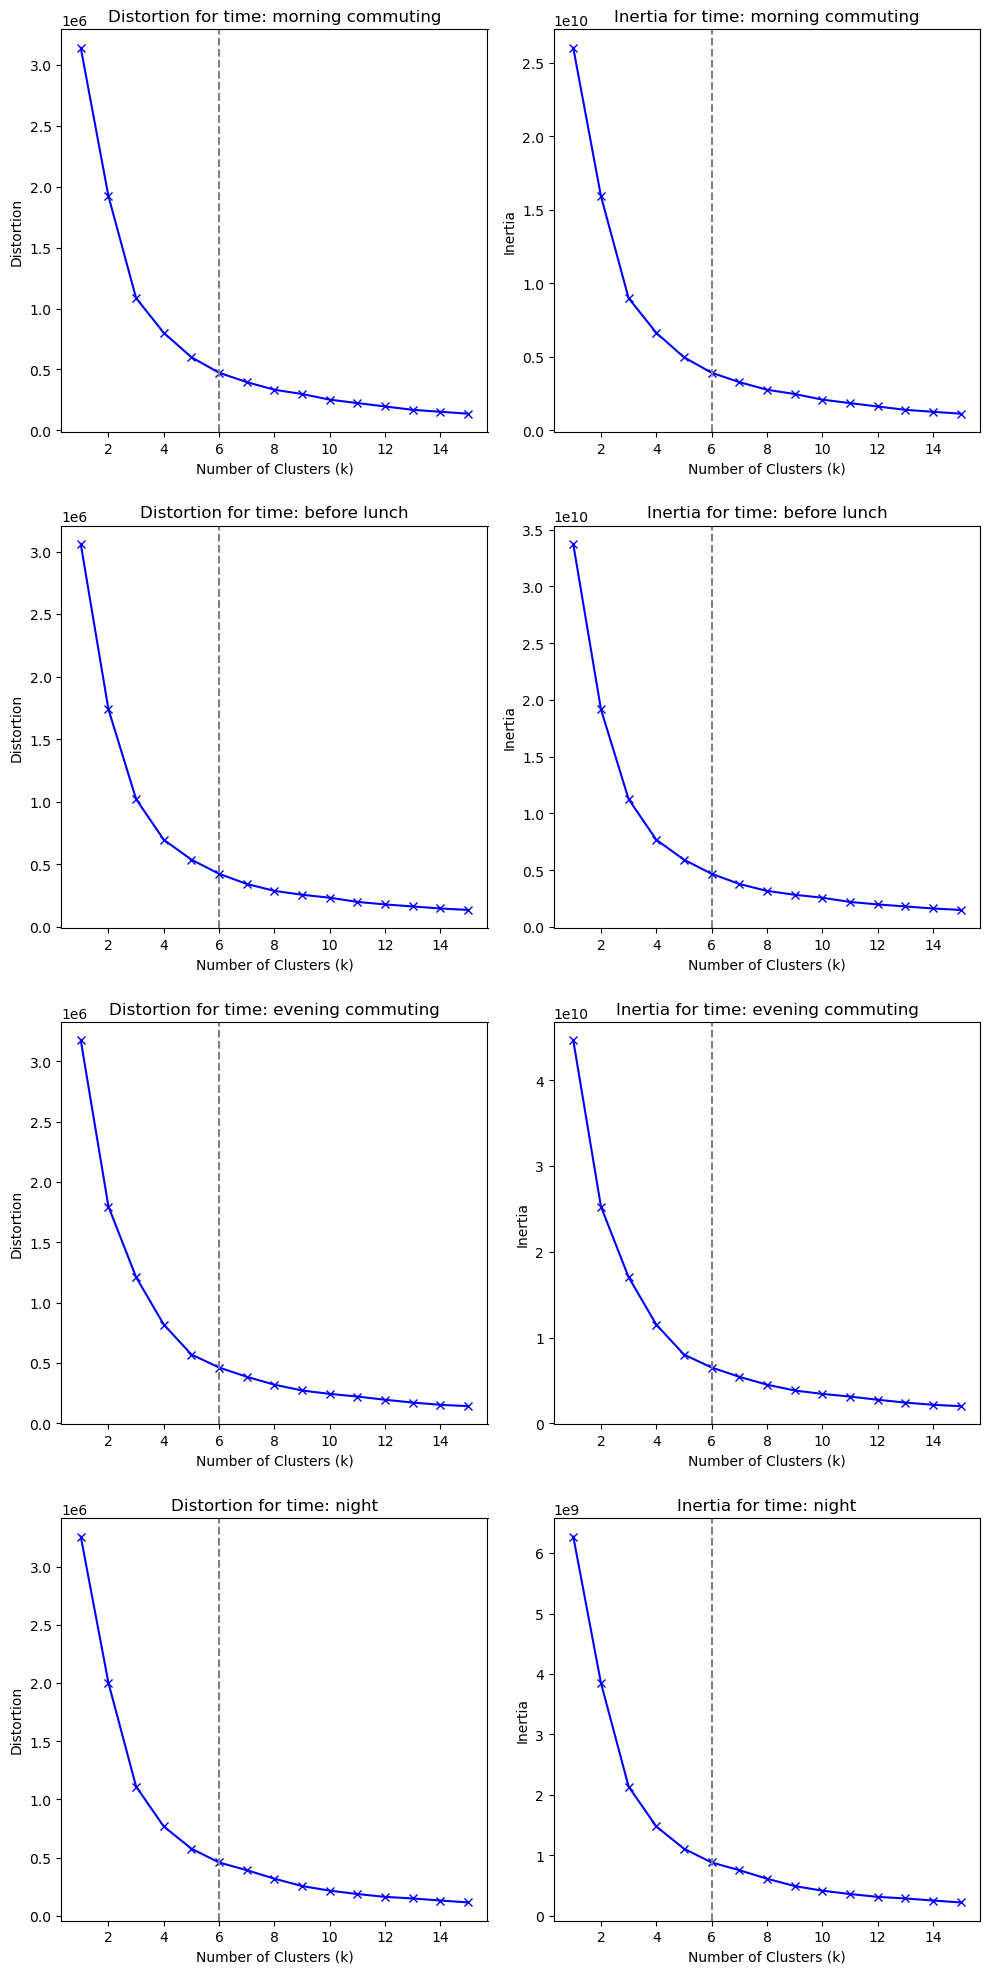

In [24]:
# plot the result
title_dict = {
0: 'midnight',
1: 'morning commuting',
2: 'before lunch',
3: 'after lunch',
4: 'evening commuting',
5: 'night',
}

fig, axg = plt.subplots(4, 2, figsize=(10, 20))

for i, hg in enumerate([1, 2, 4, 5]):
    axs = axg[i]
    ax0, ax1 = axs
    
    res = evaluation_res[hg]
    ax0.plot(res['k'], res['distortion'], 'bx-')
    ax0.set_xlabel('Number of Clusters (k)')
    ax0.set_ylabel('Distortion')
    ax0.set_title('Distortion for time: {}'.format(title_dict[hg]))
    
    ax1.plot(res['k'], res['inertia'], 'bx-')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia')
    ax1.set_title('Inertia for time: {}'.format(title_dict[hg]))
    
    for ax in axs:
        ax.axvline(x=6, ls='--', c='grey')
plt.tight_layout()
#fig.savefig('kmeans_distrotion_inertia.png', dpi=150, bbox_inches='tight')

seems like 6 is a reasonable k

For more analysis on Silhouette Score, please refer to the following page: 
https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

## DBSCAN (using all points)

In [25]:
Xb = np.array(QT[['xx', 'yy']])
Xb

array([[24974.59323777, 30737.56669471],
       [23142.41210543, 31177.56971871],
       [22056.86422679, 30512.04028262],
       ...,
       [22442.82741755, 30743.90796251],
       [22284.70596663, 31900.52448733],
       [22283.59453273, 31972.72991749]])

In [26]:
db_a = DBSCAN(eps=100, min_samples=50).fit(Xb)
db_a

DBSCAN(eps=100, min_samples=50)

In [27]:
labels = db_a.labels_

labels

array([0, 0, 1, ..., 0, 0, 0])

In [28]:

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 48
Estimated number of noise points: 1968


In [29]:
QT['dbscan_all'] = labels

In [30]:
QT.groupby(['dbscan_all'])[['did']].count()

,did
dbscan_all,
-1,1968
0,44120
1,369
2,143
3,1877
4,3156
5,232
6,1395
7,673


<Axes: >

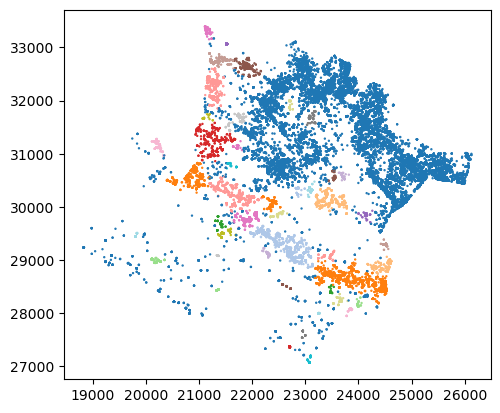

In [31]:
QT.plot('dbscan_all', marker='.', markersize=2, cmap='tab20')

## run DBSCAN for different hour groups

In [32]:
clrs = sns.color_palette('tab20')
clrs

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (1.0, 0.7333333333333333, 0.47058823529411764),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (1.0, 0.596078431372549, 0.5882352941176471),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.9686274509803922, 0.7137254901960784, 0.8235294117647058),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7803921568627451, 0.7803921568627451, 0.7803921568627451),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.8588235294117647, 0.8588235294117647, 0.5529411764705883),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
 (0.6196078431372549, 0.8549019607843137, 0.8980392156862745)]

Working on hour group: 1, for morning commuting
Estimated number of clusters: 19
Estimated number of noise points: 664
                 did
dbscan_cluster      
 0              5479
-1               664
 5               350
 1               311
 8               228
 2               138
 9               127
 12              125
 4               123
 6                97

Working on hour group: 2, for before lunch
Estimated number of clusters: 13
Estimated number of noise points: 599
                 did
dbscan_cluster      
 1              5945
 0              2488
 4               777
-1               599
 3               294
 6               157
 7               152
 2               124
 5               123
 8               121

Working on hour group: 4, for evening commuting
Estimated number of clusters: 8
Estimated number of noise points: 377
                 did
dbscan_cluster      
 1              6822
 0              3832
 4              1359
 2               708
 3               

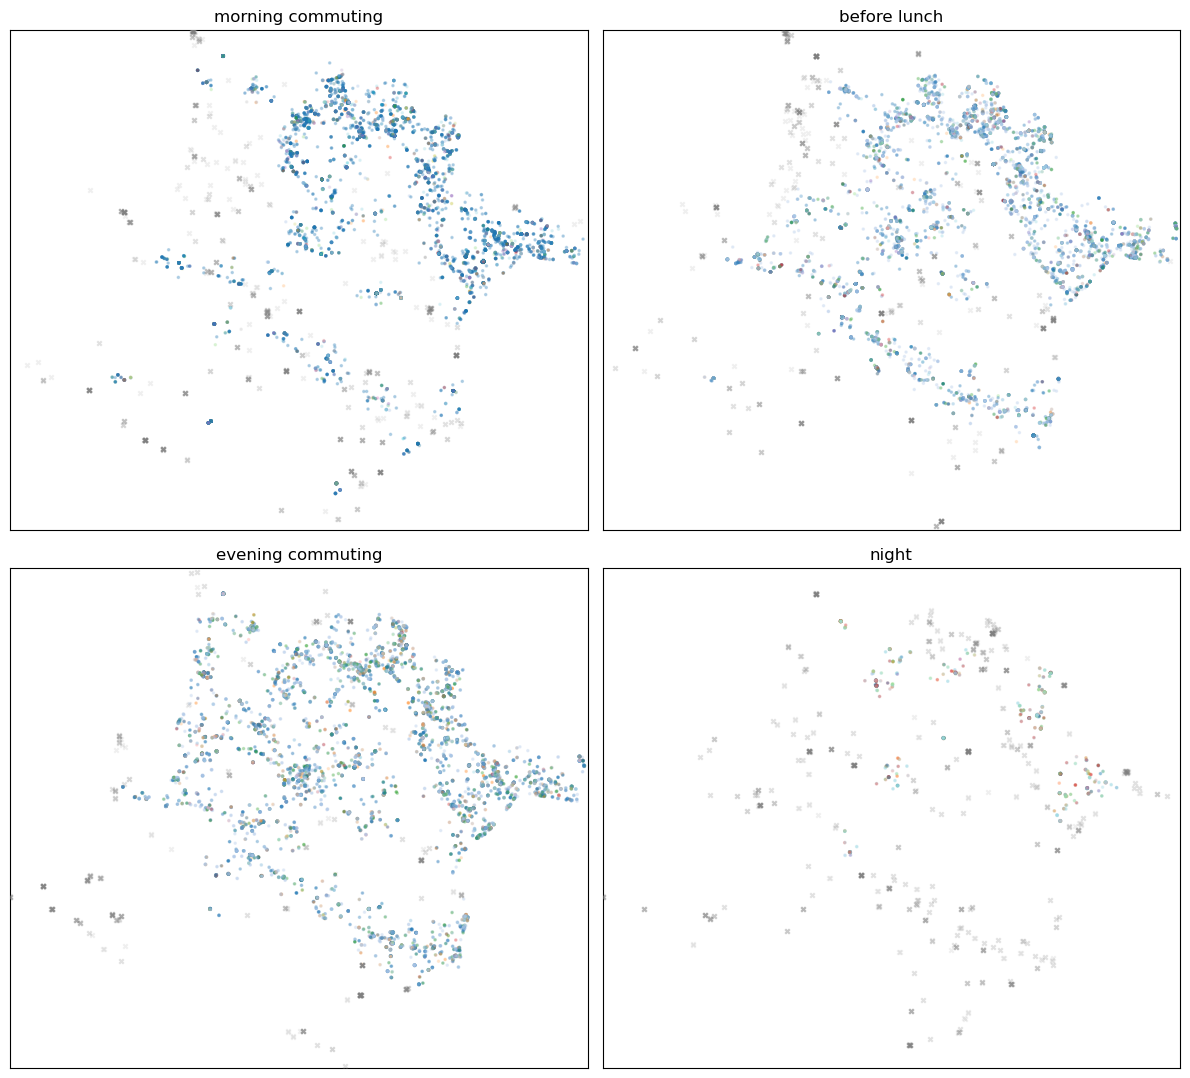

In [33]:

fig, axg = plt.subplots(2, 2, figsize=(12, 11), sharex=True, sharey=True)
axs = axg.flatten()


title_dict = {
0: 'midnight',
1: 'morning commuting',
2: 'before lunch',
3: 'after lunch',
4: 'evening commuting',
5: 'night',
}

for i, hg in enumerate([1, 2, 4, 5]):
    print('Working on hour group: {}, for {}'.format(hg, title_dict[hg]))
    ax = axs[i]
    this_gdf = this_pts[this_pts['hour_group']==hg].copy()
    Xb = np.array([this_gdf.geometry.x, this_gdf.geometry.y]).T
    
    db_tmp = DBSCAN(eps=200, min_samples=50).fit(Xb)
    labels = db_tmp.labels_
    
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)
    
    print("Estimated number of clusters: %d" % n_clusters_)
    print("Estimated number of noise points: %d" % n_noise_)
    
    this_gdf['dbscan_cluster'] = labels
    tmp_count = this_gdf.groupby(['dbscan_cluster'])[['did']].count().sort_values(by='did', ascending=False)
    print(tmp_count.head(10))
    
    #print(this_gdf)
    tmp = this_gdf[this_gdf['dbscan_cluster']!=-1]
    tmp.plot(color=[clrs[k%20] for k in labels], 
             marker=".", alpha=.25, markersize=10, 
             zorder=5, ax=ax, )
    tmp2 = this_gdf[this_gdf['dbscan_cluster']==-1]
    tmp2.plot(color='grey', 
              marker="x", alpha=.125, markersize=10, 
              zorder=5, ax=ax, )
    
    
    ax.set_title(title_dict[hg])
    xlim = (x0, x1)
    ylim = (y0, y1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    print()
plt.tight_layout()

In [71]:
min_samples = 50

sorted_distance_list = []

for i, hg in enumerate([1, 2, 4, 5]):
    print('Working on hour group: {}, for {}'.format(hg, title_dict[hg]))
    this_gdf = this_pts[this_pts['hour_group']==hg].copy()
    Xb = np.array([this_gdf.geometry.x, this_gdf.geometry.y]).T
    
    this_tree = spatial.KDTree(Xb)
    dd, ii = this_tree.query(Xb, k=min_samples)

    distance_to_min_samples = [d[-1] for d in dd]
    distance_to_min_samples = sorted(distance_to_min_samples)
    sorted_distance_list.append(distance_to_min_samples)

Working on hour group: 1, for morning commuting
Working on hour group: 2, for before lunch
Working on hour group: 4, for evening commuting
Working on hour group: 5, for night


6627
7456
7870
8201
8820
9922
10474
10915
11254
12660
13364
13926
1540
1732
1829
1906


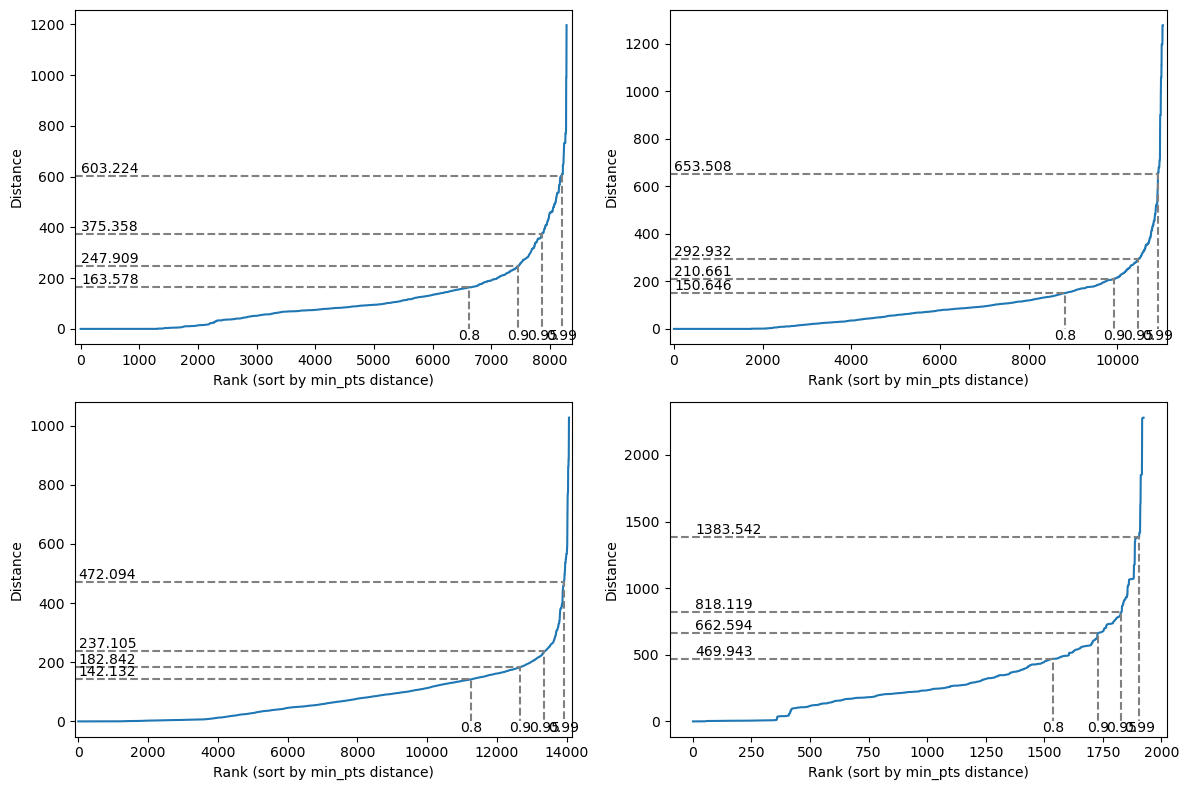

In [72]:

fig, axg = plt.subplots(2, 2, figsize=(12, 8))
axs = axg.flatten()

minx = -100
#maxx = max([len(a) for a in sorted_distance_list]) + 50
eps_dict = {}
for i, (hg, distance_to_min_samples) in enumerate(zip([1, 2, 4, 5], sorted_distance_list)):
    ax = axs[i]
    ax.plot(list(range(len(distance_to_min_samples))), distance_to_min_samples)

    maxx = len(distance_to_min_samples) + 100
    dis = {}
    for pc in [.8, .9, .95, .99]:
        ninety_pc = int(round(len(distance_to_min_samples) * pc))
        print(ninety_pc)
        h = distance_to_min_samples[ninety_pc-1]
        ax.plot([minx, ninety_pc-1, ninety_pc-1], [h, h, 0], c='grey', ls='--')
        ax.text(10, h+.001, '{:.3f}'.format(h), ha='left', va='bottom')
        ax.text(ninety_pc, 0, pc, ha='center', va='top')
        dis[pc] = h
    eps_dict[hg] = dis
    ax.set_xlabel('Rank (sort by min_pts distance)')
    ax.set_ylabel('Distance')
    ax.set_xlim([minx, maxx])
    #ax.set_ylim([0, 0.7])
plt.tight_layout()

Working on hour group: 1, for morning commuting
Estimated number of clusters: 5
Estimated number of noise points: 169
                 did
dbscan_cluster      
 0              7769
-1               169
 4               125
 3                99
 1                72
 2                50

Working on hour group: 2, for before lunch
Estimated number of clusters: 3
Estimated number of noise points: 235
                  did
dbscan_cluster       
 0              10612
-1                235
 2                108
 1                 70

Working on hour group: 4, for evening commuting
Estimated number of clusters: 4
Estimated number of noise points: 260
                  did
dbscan_cluster       
 0              12926
 1                591
-1                260
 3                238
 2                 52

Working on hour group: 5, for night
Estimated number of clusters: 1
Estimated number of noise points: 38
                 did
dbscan_cluster      
 0              1887
-1                38



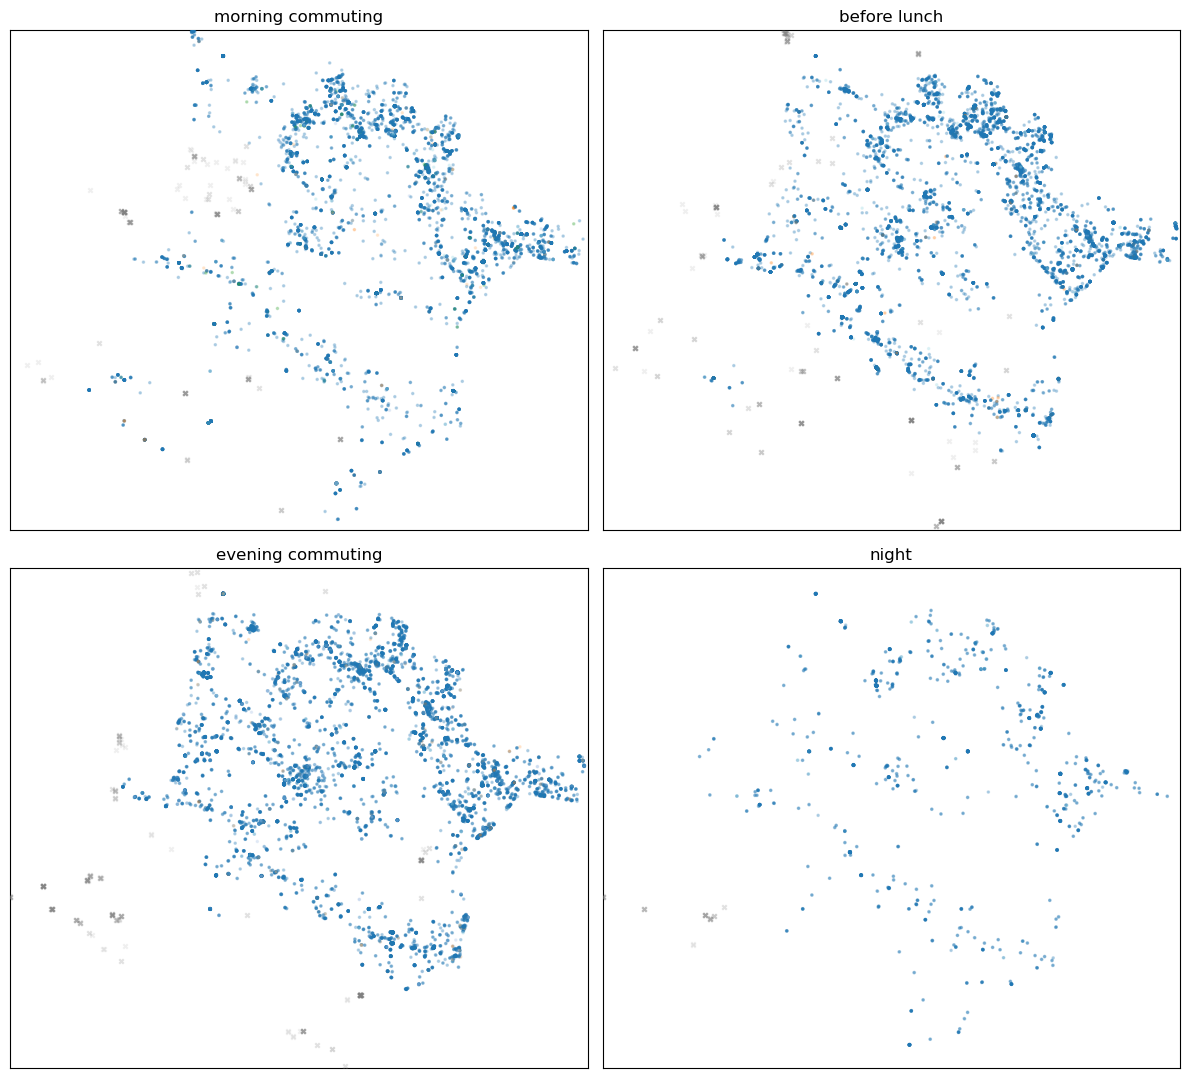

In [73]:

fig, axg = plt.subplots(2, 2, figsize=(12, 11), sharex=True, sharey=True)
axs = axg.flatten()


title_dict = {
0: 'midnight',
1: 'morning commuting',
2: 'before lunch',
3: 'after lunch',
4: 'evening commuting',
5: 'night',
}

for i, hg in enumerate([1, 2, 4, 5]):
    print('Working on hour group: {}, for {}'.format(hg, title_dict[hg]))
    ax = axs[i]
    this_gdf = this_pts[this_pts['hour_group']==hg].copy()
    Xb = np.array([this_gdf.geometry.x, this_gdf.geometry.y]).T
    eps = eps_dict[hg][.95]
    db_tmp = DBSCAN(eps=eps, min_samples=50).fit(Xb)
    labels = db_tmp.labels_
    
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)
    
    print("Estimated number of clusters: %d" % n_clusters_)
    print("Estimated number of noise points: %d" % n_noise_)
    
    this_gdf['dbscan_cluster'] = labels
    tmp_count = this_gdf.groupby(['dbscan_cluster'])[['did']].count().sort_values(by='did', ascending=False)
    print(tmp_count.head(10))
    
    #print(this_gdf)
    tmp = this_gdf[this_gdf['dbscan_cluster']!=-1]
    tmp.plot(color=[clrs[k%20] for k in labels], 
             marker=".", alpha=.25, markersize=10, 
             zorder=5, ax=ax, )
    tmp2 = this_gdf[this_gdf['dbscan_cluster']==-1]
    tmp2.plot(color='grey', 
              marker="x", alpha=.125, markersize=10, 
              zorder=5, ax=ax, )
    
    
    ax.set_title(title_dict[hg])
    xlim = (x0, x1)
    ylim = (y0, y1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    print()
plt.tight_layout()

In [34]:
min_samples_prop = .01 # 1%

sorted_distance_list = []
min_pts_list = {}

for i, hg in enumerate([1, 2, 4, 5]):
    print('Working on hour group: {}, for {}'.format(hg, title_dict[hg]))
    this_gdf = this_pts[this_pts['hour_group']==hg].copy()
    Xb = np.array([this_gdf.geometry.x, this_gdf.geometry.y]).T

    min_samples = int(round(len(this_gdf) * min_samples_prop))
    print(min_samples)
    min_pts_list[hg] = min_samples
    
    this_tree = spatial.KDTree(Xb)
    dd, ii = this_tree.query(Xb, k=min_samples)

    distance_to_min_samples = [d[-1] for d in dd]
    distance_to_min_samples = sorted(distance_to_min_samples)
    sorted_distance_list.append(distance_to_min_samples)

Working on hour group: 1, for morning commuting
83
Working on hour group: 2, for before lunch
110
Working on hour group: 4, for evening commuting
141
Working on hour group: 5, for night
19


5799
6627
7456
7870
8201
7717
8820
9922
10474
10915
9847
11254
12660
13364
13926
1348
1540
1732
1829
1906


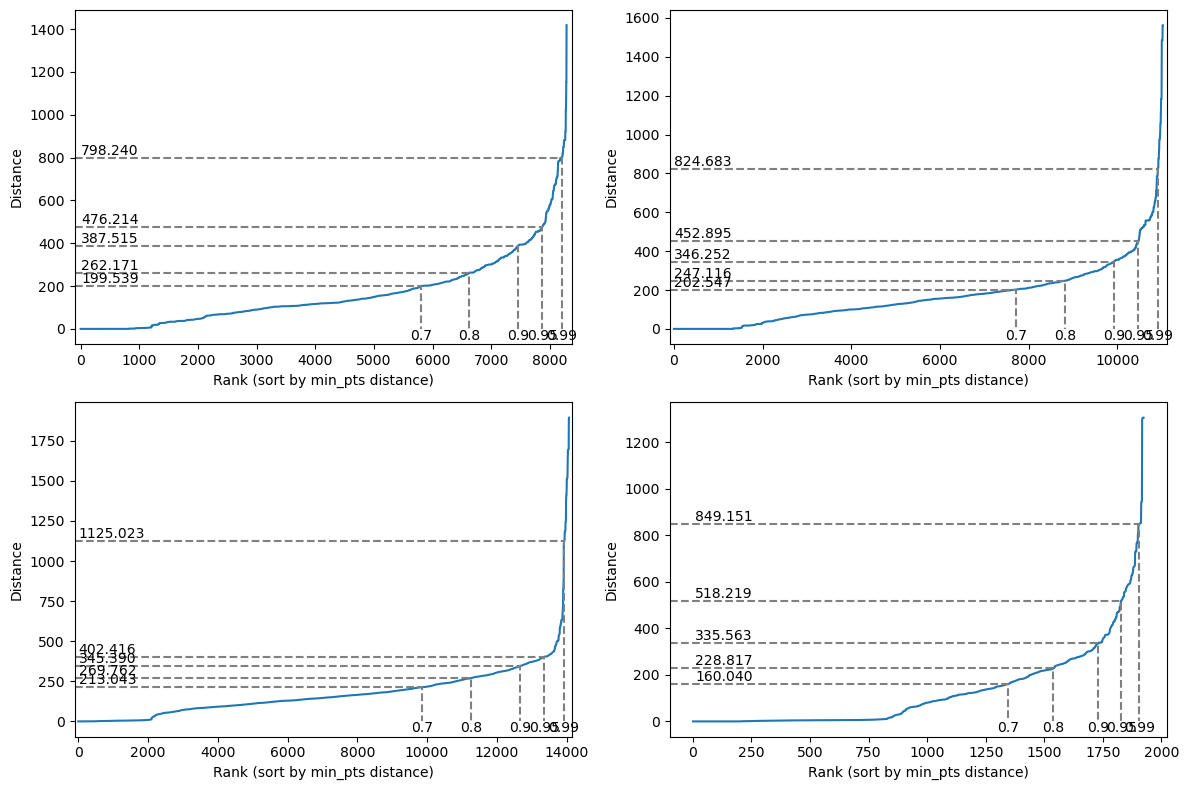

In [35]:

fig, axg = plt.subplots(2, 2, figsize=(12, 8))
axs = axg.flatten()

minx = -100
#maxx = max([len(a) for a in sorted_distance_list]) + 50
eps_dict = {}
for i, (hg, distance_to_min_samples) in enumerate(zip([1, 2, 4, 5], sorted_distance_list)):
    ax = axs[i]
    ax.plot(list(range(len(distance_to_min_samples))), distance_to_min_samples)

    maxx = len(distance_to_min_samples) + 100
    dis = {}
    for pc in [.7, .8, .9, .95, .99]:
        ninety_pc = int(round(len(distance_to_min_samples) * pc))
        print(ninety_pc)
        h = distance_to_min_samples[ninety_pc-1]
        ax.plot([minx, ninety_pc-1, ninety_pc-1], [h, h, 0], c='grey', ls='--')
        ax.text(10, h+.001, '{:.3f}'.format(h), ha='left', va='bottom')
        ax.text(ninety_pc, 0, pc, ha='center', va='top')
        dis[pc] = h
    eps_dict[hg] = dis
    ax.set_xlabel('Rank (sort by min_pts distance)')
    ax.set_ylabel('Distance')
    ax.set_xlim([minx, maxx])
    #ax.set_ylim([0, 0.7])
plt.tight_layout()

Working on hour group: 1, for morning commuting
Estimated number of clusters: 11
Estimated number of noise points: 1380
                 did
dbscan_cluster      
 0              3328
 1              2052
-1              1380
 5               350
 2               289
 7               228
 3               138
 8               125
 4               123
 6                97

Working on hour group: 2, for before lunch
Estimated number of clusters: 14
Estimated number of noise points: 1602
                 did
dbscan_cluster      
 1              4099
 0              1644
-1              1602
 5               855
 11              552
 10              550
 4               357
 3               257
 8               252
 7               205

Working on hour group: 4, for evening commuting
Estimated number of clusters: 11
Estimated number of noise points: 2145
                 did
dbscan_cluster      
 1              4401
 4              2196
-1              2145
 8              1041
 3           

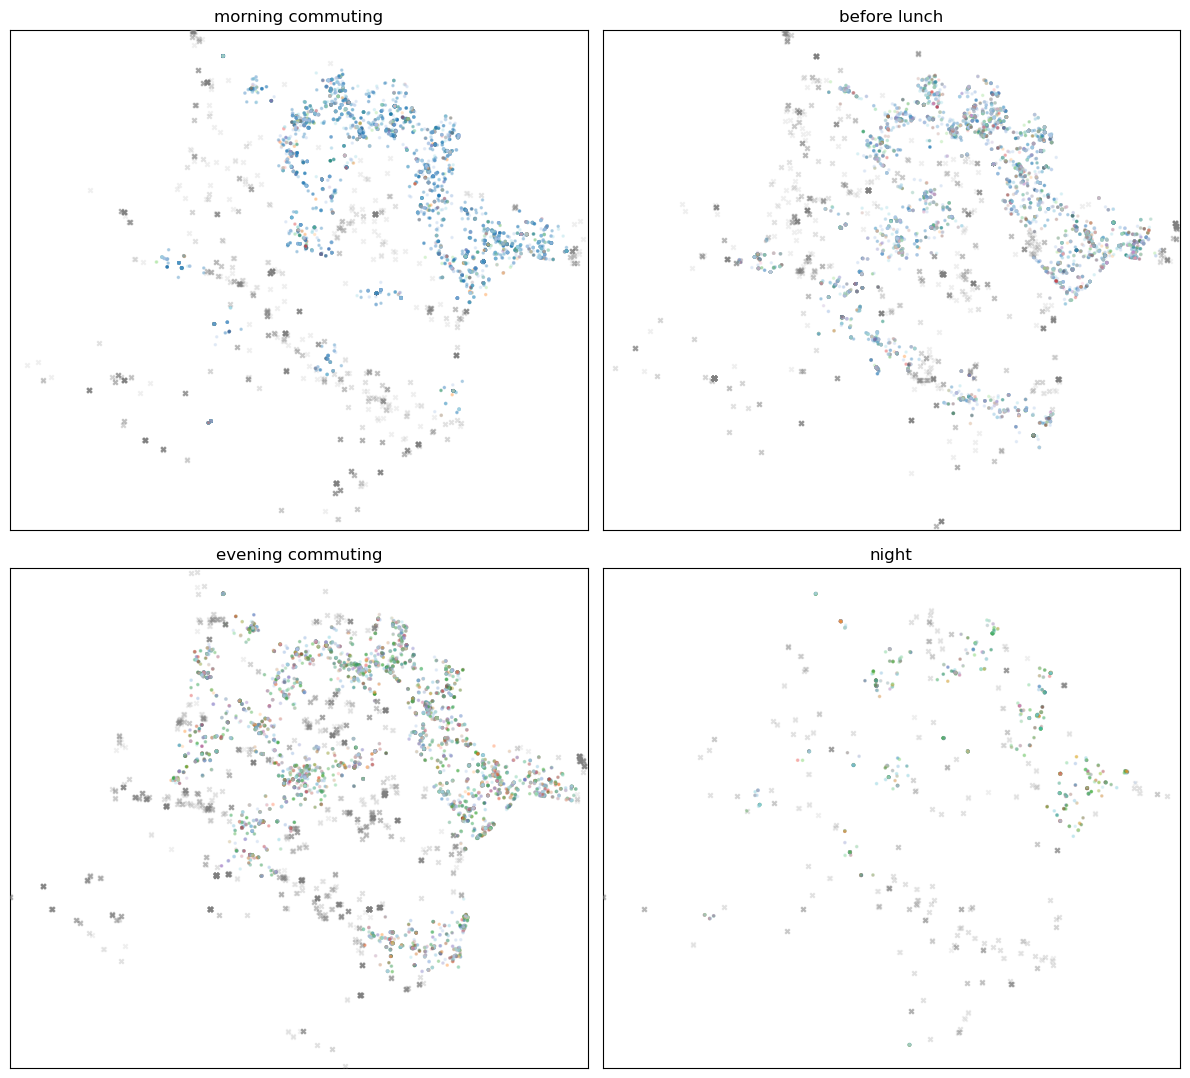

In [36]:

fig, axg = plt.subplots(2, 2, figsize=(12, 11), sharex=True, sharey=True)
axs = axg.flatten()


title_dict = {
0: 'midnight',
1: 'morning commuting',
2: 'before lunch',
3: 'after lunch',
4: 'evening commuting',
5: 'night',
}

for i, hg in enumerate([1, 2, 4, 5]):
    print('Working on hour group: {}, for {}'.format(hg, title_dict[hg]))
    ax = axs[i]
    this_gdf = this_pts[this_pts['hour_group']==hg].copy()
    Xb = np.array([this_gdf.geometry.x, this_gdf.geometry.y]).T
    eps = eps_dict[hg][.7]
    min_pts = min_pts_list[hg]
    db_tmp = DBSCAN(eps=eps, min_samples=min_pts).fit(Xb)
    labels = db_tmp.labels_
    
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)
    
    print("Estimated number of clusters: %d" % n_clusters_)
    print("Estimated number of noise points: %d" % n_noise_)
    
    this_gdf['dbscan_cluster'] = labels
    tmp_count = this_gdf.groupby(['dbscan_cluster'])[['did']].count().sort_values(by='did', ascending=False)
    print(tmp_count.head(10))
    
    #print(this_gdf)
    tmp = this_gdf[this_gdf['dbscan_cluster']!=-1]
    tmp.plot(color=[clrs[k%20] for k in labels], 
             marker=".", alpha=.25, markersize=10, 
             zorder=5, ax=ax, )
    tmp2 = this_gdf[this_gdf['dbscan_cluster']==-1]
    tmp2.plot(color='grey', 
              marker="x", alpha=.125, markersize=10, 
              zorder=5, ax=ax, )
    
    
    ax.set_title(title_dict[hg])
    xlim = (x0, x1)
    ylim = (y0, y1)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    print()
plt.tight_layout()